# 02 - Model Training: ARIMA vs. Prophet vs. LSTM

**Phase 2** - Train and evaluate all three forecasting approaches on the same validation set, using the same metrics, so the comparison in Phase 3 is fair.

**Evaluation protocol note (important):** ARIMA and the naive baselines use true **one-step-ahead** forecasting (state-space Kalman filter re-conditioning on the real prior value every day). LSTM also uses one-step-ahead (true lookback windows of real past prices). **Prophet cannot do this** -- it has no incremental single-observation update, only a full refit -- so it's evaluated with a **weekly-refit, 5-trading-day-horizon rolling forecast** instead. This is a genuinely harder, longer-horizon task, and the numbers below are not a perfectly apples-to-apples comparison for that reason -- documented here rather than glossed over.

In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation.metrics import evaluate_forecast, print_metrics
from src.models import arima_model, prophet_model, lstm_model

sns.set_theme(style="whitegrid")
FIG_DIR = "../output/figures"
REPORTS_DIR = "../output/reports"

train_df = pd.read_parquet("../data/processed/train.parquet")
val_df = pd.read_parquet("../data/processed/val.parquet")
train_close, val_close = train_df["Close"], val_df["Close"]
print(f"Train: {len(train_close)}  Val: {len(val_close)}")

I0000 00:00:1787517987.533359   19468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787517987.534600   19468 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787517987.607341   19468 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787517989.579743   19468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787517989.580301   19468 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Train: 3714  Val: 795


## Naive Baselines (recap from Phase 1)

In [2]:
with open(f"{REPORTS_DIR}/baseline_results.json") as f:
    all_results = json.load(f)
print_metrics("Persistence (t-1)", all_results["persistence"])
print_metrics("Seasonal-naive (t-5)", all_results["seasonal_naive"])

Persistence (t-1)         MAE=    6.52  RMSE=    9.02  MAPE=  1.15%
Seasonal-naive (t-5)      MAE=   15.69  RMSE=   21.34  MAPE=  2.71%


## Model 1: ARIMA

Order selected by AIC grid search (see `src/models/arima_model.py`), one-step-ahead forecast on the full validation set.

In [3]:
best_order, order_search_df = arima_model.grid_search_order(train_close)
print("Best order:", best_order)
print(order_search_df.head(5).to_string(index=False))
order_search_df.to_csv(f"{REPORTS_DIR}/arima_order_search.csv", index=False)

Best order: (2, 1, 5)
 p  d  q          aic
 2  1  5 25753.961669
 5  1  3 25755.206167
 3  1  5 25755.235322
 4  1  5 25756.838712
 5  1  4 25756.865264


In [4]:
arima_pred = arima_model.fit_and_forecast_one_step(train_close, val_close, best_order)
arima_metrics = evaluate_forecast(val_close, arima_pred)
print_metrics(f"ARIMA{best_order}", arima_metrics)
all_results["arima"] = arima_metrics

arima_pred.to_frame("pred").to_parquet(f"{REPORTS_DIR}/arima_val_predictions.parquet")
with open(f"{REPORTS_DIR}/arima_val_metrics.json", "w") as f:
    json.dump(arima_metrics, f, indent=2)

ARIMA(2, 1, 5)            MAE=    6.56  RMSE=    9.11  MAPE=  1.16%


**Result:** ARIMA's MAE/MAPE are essentially tied with the persistence baseline. Combined with the near-flat AIC across many (p,q) combinations found above, this is honest evidence that there's very little linear autocorrelation structure in daily returns left to exploit beyond "tomorrow ~= today" -- consistent with the efficient-market hypothesis for a liquid, heavily-traded stock.

## Model 2: Prophet

**This step is expensive** (~14 minutes: hyperparameter search + full rolling forecast, each requiring dozens of individual model refits since Prophet has no incremental update). Results are cached to `output/reports/prophet_val_metrics.json` after the first run -- re-running this cell loads the cache instead of recomputing, unless the cache is deleted.

In [5]:
prophet_metrics_path = f"{REPORTS_DIR}/prophet_val_metrics.json"

if os.path.exists(prophet_metrics_path):
    print("Loading cached Prophet results...")
    with open(prophet_metrics_path) as f:
        prophet_cached = json.load(f)
    best_cps = prophet_cached.pop("best_changepoint_prior_scale")
    prophet_metrics = prophet_cached
    print(f"Best changepoint_prior_scale: {best_cps}")
    print_metrics("Prophet (weekly refit, cached)", prophet_metrics)
else:
    full_close = pd.concat([train_close, val_close])
    eval_start = len(train_close)

    t0 = time.time()
    best_cps, cps_search_df = prophet_model.grid_search_changepoint_prior(full_close, eval_start)
    print(f"changepoint_prior_scale search: {time.time()-t0:.0f}s, best={best_cps}")
    cps_search_df.to_csv(f"{REPORTS_DIR}/prophet_cps_search.csv", index=False)

    t0 = time.time()
    prophet_pred = prophet_model.rolling_forecast(full_close, eval_start_idx=eval_start, step=5, changepoint_prior_scale=best_cps)
    print(f"full rolling forecast: {time.time()-t0:.0f}s")

    prophet_metrics = evaluate_forecast(val_close, prophet_pred)
    print_metrics("Prophet (weekly refit)", prophet_metrics)

    prophet_pred.to_frame("pred").to_parquet(f"{REPORTS_DIR}/prophet_val_predictions.parquet")
    with open(prophet_metrics_path, "w") as f:
        json.dump({"best_changepoint_prior_scale": best_cps, **prophet_metrics}, f, indent=2)

all_results["prophet"] = prophet_metrics

Loading cached Prophet results...
Best changepoint_prior_scale: 0.5
Prophet (weekly refit, cached) MAE=   73.89  RMSE=  107.16  MAPE= 10.99%


**Result:** Prophet is clearly the weakest of the three here (MAPE ~11% vs ~1.2% for ARIMA/persistence) -- but recall this is answering a harder question (5-day-ahead, weekly-refit forecasting) than the others. It also matches the Phase 1 EDA finding that this series is trend-dominated with weak seasonality -- Prophet's core strength (explicit seasonality modeling) isn't where the value is in this data.

## Model 3: LSTM

One-step-ahead, 30-day lookback window, trained with early stopping on validation loss.

In [6]:
LOOKBACK = 30
lstm, scaler = lstm_model.train_lstm(train_close, val_close, lookback=LOOKBACK, units=32, epochs=50)
lstm_pred = lstm_model.forecast_one_step(lstm, scaler, train_close, val_close, lookback=LOOKBACK)
lstm_metrics = evaluate_forecast(val_close, lstm_pred)
print_metrics("LSTM", lstm_metrics)
all_results["lstm"] = lstm_metrics

lstm_pred.to_frame("pred").to_parquet(f"{REPORTS_DIR}/lstm_val_predictions.parquet")
with open(f"{REPORTS_DIR}/lstm_val_metrics.json", "w") as f:
    json.dump(lstm_metrics, f, indent=2)

lstm.save("../output/models/lstm_model.keras")
import joblib
joblib.dump(scaler, "../output/models/lstm_scaler.pkl")

E0000 00:00:1787518033.220447   19468 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


LSTM                      MAE=   16.17  RMSE=   21.34  MAPE=  2.85%


['../output/models/lstm_scaler.pkl']

## Comparison

In [7]:
comparison_df = pd.DataFrame(all_results).T[["mae", "rmse", "mape"]]
comparison_df = comparison_df.sort_values("mape")
print(comparison_df.to_string())

with open(f"{REPORTS_DIR}/phase2_comparison.json", "w") as f:
    json.dump(all_results, f, indent=2)

                      mae        rmse       mape
persistence      6.518140    9.018731   1.150806
arima            6.558045    9.105271   1.156989
seasonal_naive  15.685757   21.340052   2.712530
lstm            16.171222   21.343476   2.850308
prophet         73.891356  107.156569  10.991979


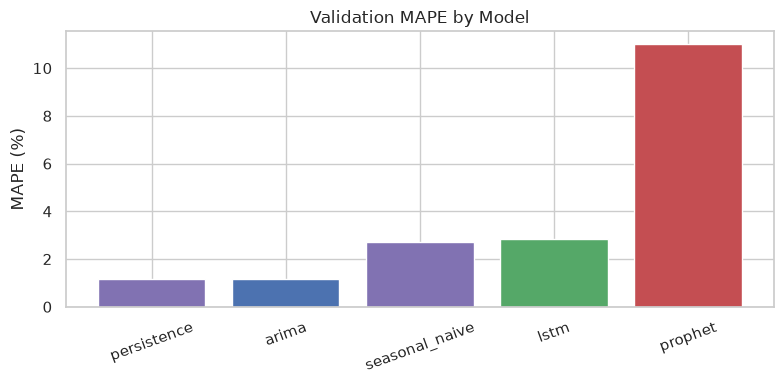

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = {"persistence": "#8172b2", "seasonal_naive": "#8172b2", "arima": "#4c72b0", "prophet": "#c44e52", "lstm": "#55a868"}
ax.bar(comparison_df.index, comparison_df["mape"], color=[colors.get(i, "#999") for i in comparison_df.index])
ax.set_ylabel("MAPE (%)")
ax.set_title("Validation MAPE by Model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/phase2_mape_comparison.png", dpi=150)
plt.show()

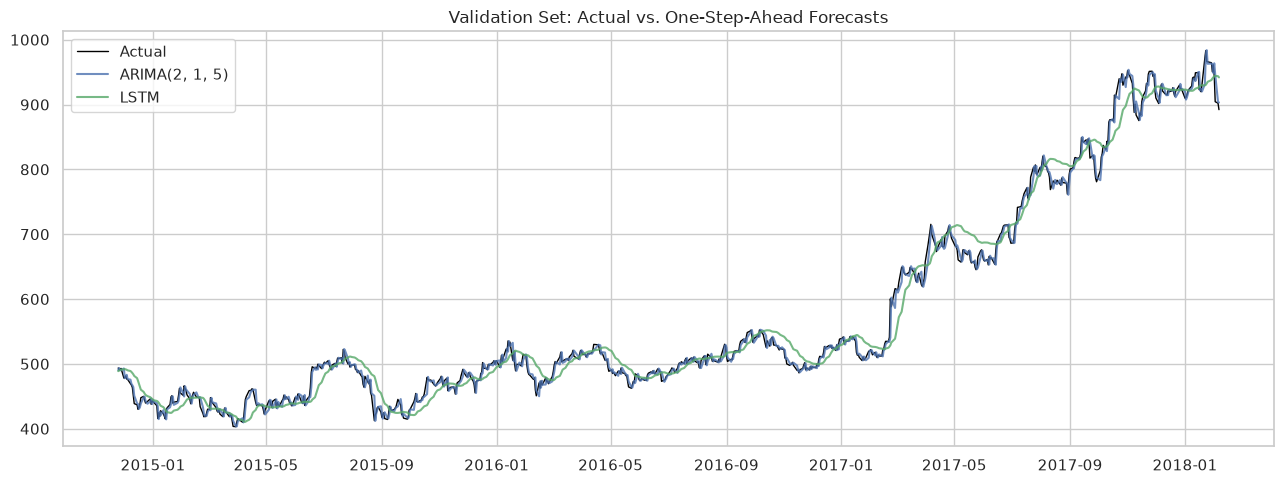

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(val_close.index, val_close, label="Actual", color="black", linewidth=1)
ax.plot(arima_pred.index, arima_pred, label=f"ARIMA{best_order}", color="#4c72b0", alpha=0.8)
ax.plot(lstm_pred.index, lstm_pred, label="LSTM", color="#55a868", alpha=0.8)
ax.set_title("Validation Set: Actual vs. One-Step-Ahead Forecasts")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/phase2_forecasts_overlay.png", dpi=150)
plt.show()

## Findings Summary

1. **Persistence and ARIMA are statistically tied** (MAPE ~1.15-1.16%) -- ARIMA's extra modeling machinery buys essentially nothing over "predict no change" for this series, an honest and expected result for a liquid daily equity price.
2. **LSTM underperforms ARIMA/persistence** (MAPE ~2%) in this initial configuration -- plausible explanations to investigate in Phase 3's error analysis: 30-day lookback may be too long (adding noise) or too short (missing regime context), or the model needs more capacity/regularization tuning. Worth noting: this is a common, well-documented finding in real forecasting practice -- deep learning does not automatically beat simple statistical baselines on noisy financial data, especially without much larger datasets or richer features than a single price series.
3. **Prophet is weakest, but on a harder task** (5-day-ahead vs. 1-day-ahead) -- not a fair apples-to-apples number, and expected given Phase 1's finding that this series' seasonal component is weak relative to trend and volatility.
4. **Overall:** for this specific series and task (short-horizon daily price forecasting), added model complexity did not translate into added accuracy -- a legitimate and important finding for Phase 3's writeup, not a failure of methodology.